<div style="display: flex; align-items: flex-start; justify-content: space-between;">
    <img src="LogoIUT.jpg" alt="Description" width="200">
    <div style="text-align: center; flex: 1; margin-top: 100px;">
        <h1>SAÉ Apprentissage pour l'IA<br>Projet</h1>
    </div>
    <div style="text-align: right;">
        BUT SD S6<br>
        2025 – 2026<br>
        NATHAN MANOHY
</div>

## Présentation du projet


In [2]:
# Imports et fonctions utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import layers
from pathlib import Path
from keras import layers
import os, pickle

MODEL_FOLDER ="../models"
RESULT_FOLDER ="../results"
Path(MODEL_FOLDER).mkdir(parents=True, exist_ok=True)
Path(RESULT_FOLDER).mkdir(parents=True, exist_ok=True)

def show_data_img(X, n=200, shape=(28,28), dpi=100):
    plt.figure(figsize=(7.195, 3.841), dpi=dpi)
    nl = n // 20
    if n%20!=0: nl += 1
    
    for i in range(n):
        plt.subplot(nl,20,i+1)
        plt.imshow(X[i,:].reshape(shape), cmap='gray')
        plt.axis('off')
    plt.plot()

def show_model_errors_rgb(model, X, y, shape=(32,32,3)):
    proba = model.predict(X)
    y_pred = proba.argmax(axis=1)
    errors = [i for i in range(len(y_pred)) if y_pred[i]!=y[i]]
    
    # Affichage manuel pour RGB
    X_err, y_pred_err, y_true_err = X[errors], y_pred[errors], y[errors]
    n = min(len(X_err), 30)
    
    plt.figure(figsize=(7.195, 3.841), dpi=100)
    nl = n // 10
    if n % 10 != 0: nl += 1
    
    for i in range(n):
        plt.subplot(nl, 10, i+1)
        plt.imshow(X_err[i])
        plt.axis('off')
        plt.title(str(y_pred_err[i]) + ' (' + str(y_true_err[i]) + ')', fontsize=8)
    
    plt.tight_layout()
    plt.show()   

Fonction pour que les graphiques soit plus propres

In [3]:
def plot_metrics(accuracy, loss):
    models = list(dict.fromkeys(
        k.replace('_train', '').replace('_val', '') 
        for k in accuracy.keys()
    ))
    
    palette = plt.cm.tab10.colors
    color_map = {model: palette[i % len(palette)] for i, model in enumerate(models)}
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    for key, values in accuracy.items():
        is_train = '_train' in key
        model = key.replace('_train', '').replace('_val', '')
        ax1.plot(values,
                 label=key,
                 color=color_map[model],
                 linewidth=2 if is_train else 1.2,
                 linestyle='-' if is_train else '--')
    ax1.set_title("Evolution de l'accuracy au cours de l'entrainement")
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    for key, values in loss.items():
        is_train = '_train' in key
        model = key.replace('_train', '').replace('_val', '')
        ax2.plot(values,
                 label=key,
                 color=color_map[model],
                 linewidth=2 if is_train else 1.2,
                 linestyle='-' if is_train else '--')
    ax2.set_title("Evolution de la loss au cours de l'entrainement")
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## Etude 2 : Classement d'images sur les données CIFAR-10

In [4]:
from keras.datasets import cifar10 
(X_train, y_train), (X_val, y_val) = cifar10.load_data()

c:\#Document\Travail\BUT 3 S2\Winequality-CIFAR10-ML-Project\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [5]:
X_train.shape

(50000, 32, 32, 3)

In [6]:
X_train = X_train / 255
X_val = X_val / 255

**Exemples d’images pour chaque classe**

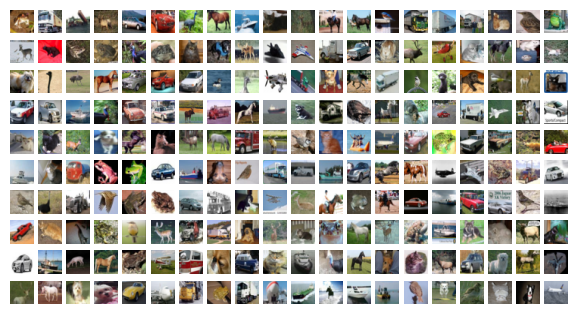

In [7]:
show_data_img(X_train, n=200, shape=(32,32,3), dpi=100)

**Répartition des classes**

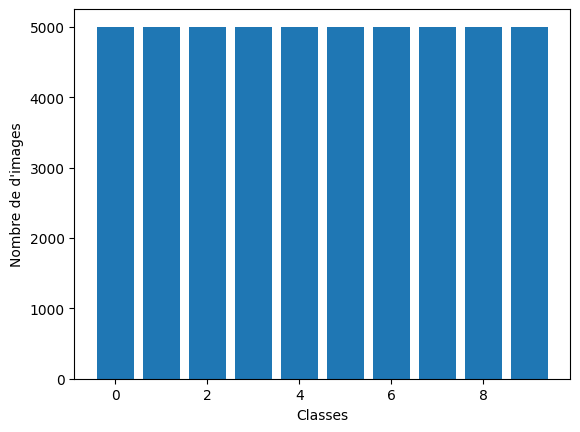

In [8]:
classes, counts = np.unique(y_train, return_counts=True)
plt.bar(classes, counts)
plt.xlabel("Classes")
plt.ylabel("Nombre de d'images")
plt.show()

In [9]:
accuracy = {}
loss = {}

In [33]:
def baseline():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(32, 32, 3)))
    m.add(keras.layers.Flatten()) # Très utile car on est sur des données sur 3 cannals (le RGB)
    m.add(keras.layers.Dense(32, activation = 'relu'))
    m.add(keras.layers.Dense(10, activation= 'softmax'))

    m.compile(optimizer='SGD', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m, "baseline"

def avance_33():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(32,32,3)))
    m.add(layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))
    m.add(layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))

    m.add(keras.layers.Flatten())
    m.add(keras.layers.Dense(10, activation='softmax'))

    m.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])
    return m, "avance_33"


def avance_55():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(32,32,3)))
    m.add(layers.Conv2D(32, kernel_size=(5,5), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))
    m.add(layers.Conv2D(64, kernel_size=(5,5), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))

    m.add(keras.layers.Flatten())
    m.add(keras.layers.Dense(10, activation='softmax'))

    m.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])
    return m, "avance_55"


def avance_augmentation_55():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(32,32,3)))
    
    m.add(layers.RandomFlip("horizontal"))
    m.add(layers.RandomRotation(0.05))

    
    m.add(layers.Conv2D(32, kernel_size=(5,5), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))
    m.add(layers.Conv2D(64, kernel_size=(5,5), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))

    m.add(keras.layers.Flatten())
    m.add(keras.layers.Dense(10, activation='softmax'))

    m.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])
    return m, "avance55_V4"


def avance_augmentation_33():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(32,32,3)))
    
    m.add(layers.RandomFlip("horizontal"))
    m.add(layers.RandomRotation(0.05))

    
    m.add(layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))
    m.add(layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))

    m.add(keras.layers.Flatten())
    m.add(keras.layers.Dense(10, activation='softmax'))

    m.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])
    return m, "avance33_V5"


In [21]:
# # Charger le modèle
# model = keras.models.load_model('../CIFAR_models/avance_augmentation_V2.keras')

# def charger_V2():
#     model = keras.models.load_model('../CIFAR_models/avance_augmentation_V2.keras')
#     return model, "avance_augmentation_V2"

In [35]:
models = [baseline,avance_33,avance_55,avance_augmentation_33,avance_augmentation_55]


taille_batch = 64
nb_iterations = 100

for model_func in models:
    model, nom = model_func()
    print(f"\n=== Entrainement de {nom} ===")
    model.summary()
    
    s = model.fit(X_train, y_train, batch_size=taille_batch, epochs=nb_iterations, verbose=1, validation_data=(X_val, y_val),callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])
    
    accuracy[nom+"_train"] = s.history['accuracy']
    accuracy[nom+"_val"] = s.history['val_accuracy']
    
    loss[nom+"_train"] = s.history['loss']
    loss[nom+"_val"] = s.history['val_loss']
    
    model.save(MODEL_FOLDER+"/CIFAR_"+nom+".keras")
    print(f"{nom} sauvegardé")

    with open(RESULT_FOLDER+"/accuracy_"+nom+".pickle", "wb") as f:
        pickle.dump({"train": s.history['accuracy'], "val": s.history['val_accuracy']}, f)
    
    with open(RESULT_FOLDER+"/loss_"+nom+".pickle", "wb") as f:
        pickle.dump({"train": s.history['loss'], "val": s.history['val_loss']}, f)


=== Entrainement de baseline ===


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │        98,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,666 (385.41 KB)

 Trainable params: 98,666 (385.41 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 10, 10, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,706 (272.29 KB)

 Trainable params: 69,706 (272.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4233 - loss: 1.5920 - val_accuracy: 0.4879 - val_loss: 1.4286
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5349 - loss: 1.3163 - val_accuracy: 0.5766 - val_loss: 1.1986
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5737 - loss: 1.2099 - val_accuracy: 0.5886 - val_loss: 1.1826
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6044 - loss: 1.1370 - val_accuracy: 0.6169 - val_loss: 1.0897
Epoch 5/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6218 - loss: 1.0842 - val_accuracy: 0.6448 - val_loss: 1.0156
Epoch 6/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6376 - loss: 1.0460 - val_accuracy: 0.6503 - val_loss: 1.0035
Epoch 7/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6515 - loss: 1.0107 - val_accuracy: 0.6674 - val_loss: 0.9734
Epoch 8/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6575 - loss: 0.9836 - val_accu

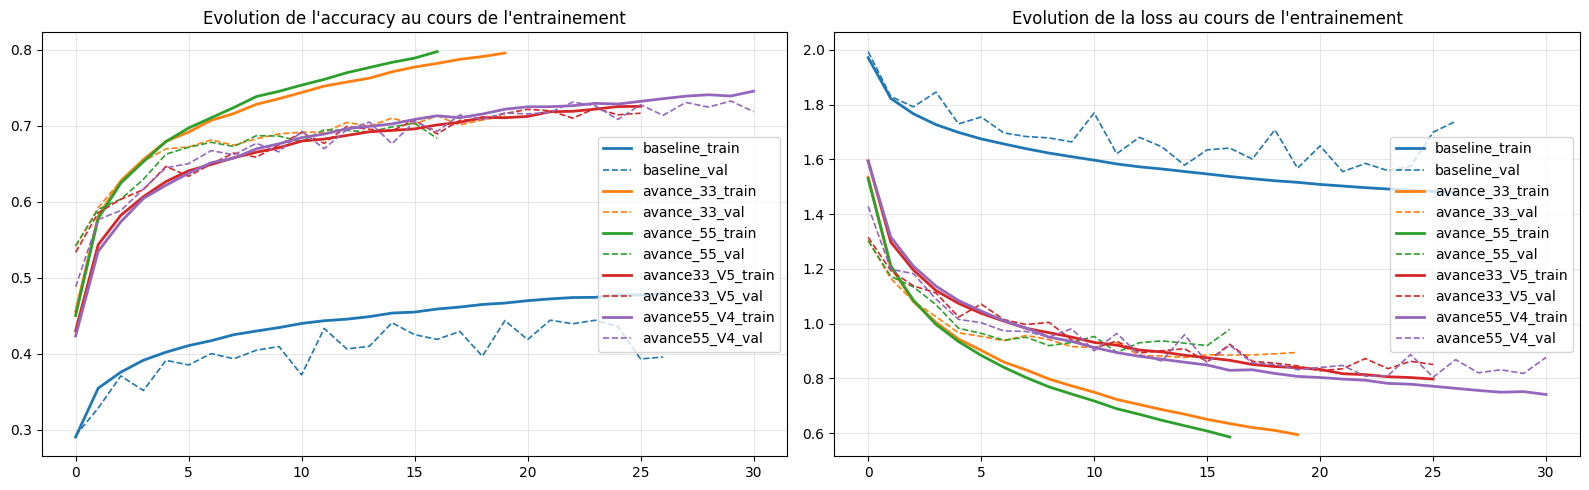

In [36]:
plot_metrics(accuracy, loss)

In [10]:
from keras.models import load_model

In [ ]:
meilleur_model = load_model(MODEL_FOLDER+"/CIFAR_avance_55.keras")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 460us/step


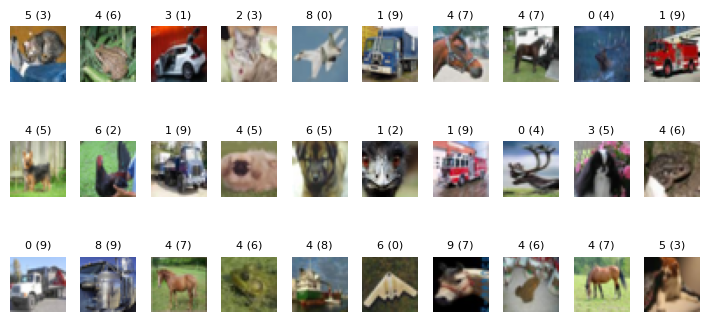

In [ ]:
# Afficher ses erreurs
show_model_errors_rgb(meilleur_model, X_val, y_val.flatten())